In [ ]:
!wget --no-check-certificate https://lazyprogrammer.me/course_files/AirlineTweets.csv

In [5]:
from transformers import pipeline
import numpy as np
import pandas as pd
import seaborn as sn

from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix

In [6]:
from dotenv import load_dotenv
import os

load_dotenv()
from huggingface_hub import login
login(token=os.getenv("HF_TOKEN"))


The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `huggingface-cli` if you want to set the git credential as well.
Token is valid (permission: write).
Your token has been saved to C:\Users\NISHIT\.cache\huggingface\token
Login successful


In [7]:
classifier = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision af0f99b (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
c:\Users\NISHIT\AppData\Local\Programs\Python\Python310\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


In [8]:
classifier("This is such a great movie!")

[{'label': 'POSITIVE', 'score': 0.9998759031295776}]

In [9]:
classifier("I can't say that this was a good movie")


[{'label': 'NEGATIVE', 'score': 0.9278469085693359}]

In [10]:
classifier([
  "This course is just what I needed.",
  "I can't understand any of this. Instructor kept telling me to meet the \
    prerequisites. What are prerequisites? Why does he keep saying that?"
])

[{'label': 'POSITIVE', 'score': 0.9991594552993774},
 {'label': 'NEGATIVE', 'score': 0.9966675639152527}]

In [11]:
import torch

torch.cuda.is_available()
torch.cuda.current_device()

0

In [12]:
classifier = pipeline("sentiment-analysis", device=0)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision af0f99b (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


In [13]:
df_ = pd.read_csv('AirlineTweets.csv')
df = df_[['airline_sentiment', 'text']].copy()
target_map = {'positive': 1, 'negative': 0}
df['target'] = df['airline_sentiment'].map(target_map)
texts = df['text'].tolist()

In [14]:
predictions = classifier(texts)

In [15]:
probs = [d['score'] if d['label'].startswith('P') else 1 - d['score'] \
         for d in predictions]

In [16]:
preds = [1 if d['label'].startswith('P') else 0 for d in predictions]
preds = np.array(preds)
print("acc:", np.mean(df['target'] == preds))

acc: 0.7015027322404371


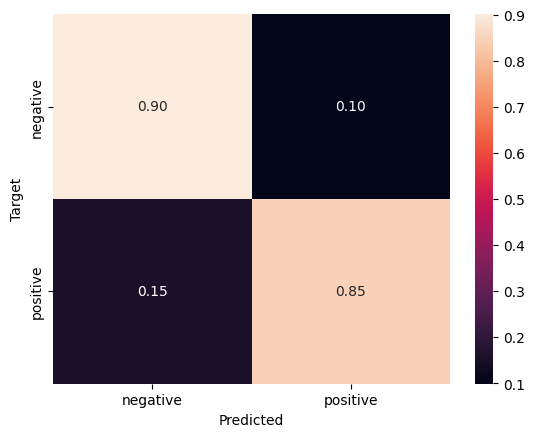

In [18]:
# filter out rows where target is NaN so confusion_matrix doesn't receive NaNs
mask = df['target'].notna()
y_true = df.loc[mask, 'target'].astype(int).values
y_pred = preds[mask.values]

cm = confusion_matrix(y_true, y_pred, normalize='true')

def plot_cm(cm):
  classes = ['negative', 'positive']
  df_cm = pd.DataFrame(cm, index=classes, columns=classes)
  ax = sn.heatmap(df_cm, annot=True, fmt='.2f')
  ax.set_xlabel("Predicted")
  ax.set_ylabel("Target")

plot_cm(cm)

In [ ]:
filtered_probs = np.array(probs)[mask.values]

print("f1:", f1_score(y_true, y_pred))
print("f1 (inverted):", f1_score(1 - y_true, 1 - y_pred))
print("roc_auc:", roc_auc_score(y_true, filtered_probs))
print("roc_auc (inverted):", roc_auc_score(1 - y_true, 1 - filtered_probs))

f1: 0.758777756690074
f1 (inverted): 0.928647616908999
roc_auc: 0.9485934229556096
roc_auc (inverted): 0.9485934229556096
